In [68]:
import pandas as pd
from pprint import pprint

df_merged = pd.read_csv("../data/processed/df_merged_features_complete.csv.zip")
df_encoded = pd.read_csv("../data/processed/df_encoded_features_complete.csv.zip")

print()
print("Verify columns in df_merged")
pprint(df_merged.columns.tolist())

/var/folders/h7/j749vy8n45n8p147xy2ll3vw0000gn/T/ipykernel_71878/3595987982.py:4: DtypeWarning: Columns (0: Persons Evacuated, 1: Division Code, 2: Train Direction Code, 3: Remote Control Locomotive Code, 4: First Car Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv("../data/processed/df_merged_features_complete.csv.zip")



Verify columns in df_merged
['Reporting Railroad Code',
 'Reporting Railroad Name',
 'Year',
 'Accident Number',
 'PDF Link',
 'Accident Year',
 'Accident Month',
 'Other Railroad Code',
 'Other Railroad Name',
 'Other Accident Number',
 'Other Accident Year',
 'Other Accident Month',
 'Maintenance Railroad Code',
 'Maintenance Railroad Name',
 'Maintenance Accident Number',
 'Maintenance Accident Year',
 'Maintenance Accident Month',
 'Grade Crossing ID',
 'Day',
 'Date',
 'Time',
 'Accident Type Code',
 'Accident Type',
 'Hazmat Cars',
 'Hazmat Cars Damaged',
 'Hazmat Released Cars',
 'Persons Evacuated',
 'Subdivision',
 'Division Code',
 'Division',
 'Station',
 'Milepost',
 'State Code',
 'State Abbreviation',
 'State Name',
 'County Code',
 'County Name',
 'District',
 'Temperature',
 'Visibility Code',
 'Visibility',
 'Weather Condition Code',
 'Weather Condition',
 'Track Type Code',
 'Track Type',
 'Track Name',
 'Track Class',
 'Track Density',
 'Train Direction Code',
 'Tra

/var/folders/h7/j749vy8n45n8p147xy2ll3vw0000gn/T/ipykernel_71878/3595987982.py:5: DtypeWarning: Columns (0: Persons Evacuated, 1: Division Code, 2: Train Direction Code, 3: Remote Control Locomotive Code, 4: First Car Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df_encoded = pd.read_csv("../data/processed/df_encoded_features_complete.csv.zip")


In [69]:
print("Verify columns in df_encoded")
pprint(df_encoded.columns.tolist())

Verify columns in df_encoded
['Reporting Railroad Code',
 'Reporting Railroad Name',
 'Year',
 'Accident Number',
 'PDF Link',
 'Accident Year',
 'Accident Month',
 'Other Railroad Code',
 'Other Railroad Name',
 'Other Accident Number',
 'Other Accident Year',
 'Other Accident Month',
 'Maintenance Railroad Code',
 'Maintenance Railroad Name',
 'Maintenance Accident Number',
 'Maintenance Accident Year',
 'Maintenance Accident Month',
 'Grade Crossing ID',
 'Day',
 'Date',
 'Time',
 'Accident Type Code',
 'Accident Type',
 'Hazmat Cars',
 'Hazmat Cars Damaged',
 'Hazmat Released Cars',
 'Persons Evacuated',
 'Subdivision',
 'Division Code',
 'Division',
 'Station',
 'Milepost',
 'State Code',
 'State Abbreviation',
 'State Name',
 'County Code',
 'County Name',
 'District',
 'Temperature',
 'Visibility Code',
 'Visibility',
 'Weather Condition Code',
 'Weather Condition',
 'Track Type Code',
 'Track Type',
 'Track Name',
 'Track Class',
 'Track Density',
 'Train Direction Code',
 'Tra

In [70]:
# Select the shortlist categorical columns for one-hot encoding
cols_to_ohe = [
    'Weather Condition', 
    'Track Type', 
    'Visibility', 
    'Accident Type', 
    'Region', 
    'RUCC_2023',
    'Equipment Type'
]

# Create df_ohe with one-hot encoded variables (used later for Assocation Rule Mining (ARM) model. 
# pd.get_dummies will automatically convert these categorical columns to 0/1 subfeature of each original column
df_ohe = pd.get_dummies(
    df_merged[cols_to_ohe], 
    columns=cols_to_ohe, 
    dtype=int 
)

# Verify the new dataframe
print(f"Shape of df_ohe: {df_ohe.shape}")
pprint(df_ohe.columns.tolist()[::2]) 
df_ohe.head()

Shape of df_ohe: (34562, 54)
['Weather Condition_Clear',
 'Weather Condition_Fog',
 'Weather Condition_Sleet',
 'Track Type_Industry',
 'Track Type_Siding',
 'Visibility_Dark',
 'Visibility_Day',
 'Accident Type_Broken train collision',
 'Accident Type_Explosion-detonation',
 'Accident Type_Head on collision',
 'Accident Type_Obstruction',
 'Accident Type_Other impacts',
 'Accident Type_Raking collision',
 'Accident Type_Side collision',
 'Region_Northeast',
 'Region_West',
 'RUCC_2023_2',
 'RUCC_2023_4',
 'RUCC_2023_6',
 'RUCC_2023_8',
 'Equipment Type_Commuter Train - Pulling',
 'Equipment Type_Cut of cars',
 'Equipment Type_EMU',
 'Equipment Type_Light loco(s)',
 'Equipment Type_Passenger Train - Pulling',
 'Equipment Type_Single Car',
 'Equipment Type_Work train']


,Weather Condition_Clear,Weather Condition_Cloudy,Weather Condition_Fog,Weather Condition_Rain,Weather Condition_Sleet,Weather Condition_Snow,Track Type_Industry,Track Type_Main,Track Type_Siding,Track Type_Yard,...,Equipment Type_EMU,Equipment Type_Freight Train,Equipment Type_Light loco(s),Equipment Type_Maint./inspect Car,Equipment Type_Passenger Train - Pulling,Equipment Type_Passenger Train - Pushing,Equipment Type_Single Car,Equipment Type_Spec. MoW Equip.,Equipment Type_Work train,Equipment Type_Yard/switching
0,1,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## One-Hot Encoding for ARM Analysis

Convert selected categorical features into binary format required for Association Rule Mining. ARM algorithms treat each category level as a distinct "item" in transaction analysis, requiring explicit binary columns rather than numeric encodings.

**Features selected for encoding:**
- Weather Condition: Environmental context
- Track Type: Operational setting  
- Visibility: Lighting conditions
- Accident Type: Incident classification
- Region: US Census geographic region
- RUCC_2023: Rural-urban continuum classification
- Equipment Type: Train operational type

**Why One-Hot Encoding:**
ARM generates rules like "IF Track_Yard AND Weather_Clear THEN Cause_Human". Each category level must be a discrete binary feature (present=1, absent=0) to form interpretable itemsets. Binary encoding would create non-interpretable bit patterns unsuitable for rule generation.

The `pd.get_dummies()` function creates a new binary column for each category level across all selected features, transforming the dataset into the transactional format required by ARM algorithms (Apriori, FP-Growth).

In [71]:
from sklearn.model_selection import train_test_split

# Drop rows where the Target (Cause_Category) is missing
# We must do this before creating X to ensure X and y have the same number of rows
df_clean = df_merged.dropna(subset=['Cause_Category']).copy()

print(f"Original rows: {len(df_merged)}")
print(f"Rows after dropping missing Cause Codes: {len(df_clean)}")

# Re-create the features (X) using the clean dataframe
# We use the same columns as before
cols_to_encode = [
    'Weather Condition', 
    'Track Type', 
    'Visibility', 
    'Accident Type', 
    'Region', 
    'RUCC_2023'
]

# Create X (features)
X = pd.get_dummies(
    df_clean[cols_to_encode], 
    columns=cols_to_encode, 
    dtype=int
)

# Create y (target)
y = df_clean['Cause_Category']

# Create the 80/20 train-test split
# stratify=y works now because y has no NaNs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify the shapes
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Original rows: 34562
Rows after dropping missing Cause Codes: 34560
Training set shape: (27648, 40)
Testing set shape:  (6912, 40)


## Random Forest Model Training

Initialize and train a Random Forest classifier to establish an accuracy benchmark for comparison with the ARM-CBA approach.

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Model training complete.")

Training Random Forest model...
Model training complete.


## Random Forest Evaluation: Accuracy and Classification Report

Evaluate overall model performance and per-class accuracy using precision, recall, and F1-scores to assess how well the model handles class imbalance.

**Interpreting Results:**
- Accuracy: Overall percentage of correct predictions
- Precision: Of predictions for cause X, what percentage were correct?
- Recall: Of actual cause X accidents, what percentage were identified?
- F1-Score: Balance between precision and recall - use this to compare cause categories

In [73]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5670

Classification Report:
              precision    recall  f1-score   support

           E       0.44      0.22      0.29       744
           H       0.56      0.76      0.64      2716
           M       0.79      0.54      0.64      1771
           S       0.39      0.04      0.07       174
           T       0.46      0.48      0.47      1507

    accuracy                           0.57      6912
   macro avg       0.52      0.41      0.42      6912
weighted avg       0.58      0.57      0.55      6912



## Random Forest Findings: Performance Analysis

**Overall Performance:**
The Random Forest model achieved 57% accuracy, indicating moderate predictive power. This baseline reveals significant challenges in separating accident cause categories using the selected operational and environmental features.

**Per-Class Performance Breakdown:**

*Strong Performance:*
- Human Factor (H): 76% recall - the model successfully identifies three-quarters of Human Factor accidents, though precision is only 56% (some false positives)

*Moderate Performance:*
- Mechanical (M): High precision (79%) but moderate recall (54%) - when the model predicts Mechanical, it's usually correct, but it misses nearly half of actual Mechanical failures
- Track (T): Balanced but weak at 47-48% for both precision and recall

*Poor Performance:*
- Equipment (E): 22% recall - missing 78% of Equipment failures
- Signal (S): 4% recall - effectively failing to identify Signal accidents (catches only 1 in 25)

**What This Reveals:**

The model struggles most with minority classes (Signal at 2.5% of data, Equipment at 11%). Human Factor dominates predictions due to being the majority class (39%). The low macro F1-score (0.42) confirms that performance is not balanced across categories.

**Feature Overlap Hypothesis:**
The moderate accuracy suggests that operational/environmental conditions for different accident causes overlap considerably. A Yard track accident in clear weather could be Human, Mechanical, or Equipment-related depending on factors not captured in our feature set.

**Implications for ARM/CBA:**
This baseline establishes that approximately 57% accuracy represents strong performance for this feature set and problem complexity. If ARM/CBA achieves accuracy in the 50-60% range while providing interpretable rules, it offers competitive performance with the added benefit of actionable insights. The real value of ARM will be whether discovered rules reveal interpretable patterns that explain WHY certain causes are difficult to distinguish.

## Random Forest Feature Importance Analysis

Identify which features most strongly influence accident cause predictions based on their contribution to reducing impurity across all decision trees.

**Interpreting Results:**
Higher importance scores indicate features that better separate cause categories. Compare these rankings to features appearing frequently in ARM rules to assess consistency between black-box and rule-based approaches.

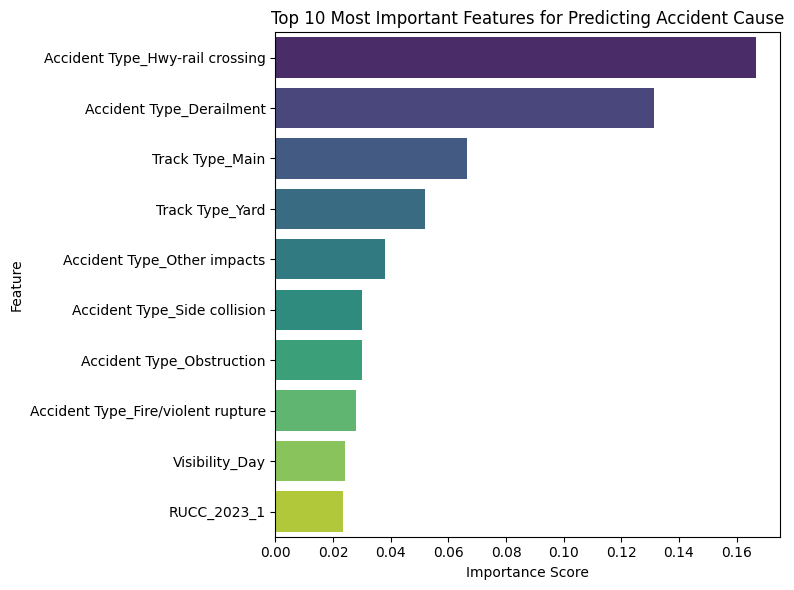

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Features for Predicting Accident Cause')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Feature Importance Findings

**Accident Type Dominates:**
Highway-rail crossing and Derailment accident types are the strongest predictors of cause categories, with importance scores significantly higher than other features. This suggests that the nature of the incident itself (collision vs derailment vs obstruction) provides substantial information about the underlying cause.

**Track Type Matters:**
Main and Yard track types appear in the top 10, indicating operational setting influences cause patterns. This aligns with Phase 2 EDA findings showing Yards have higher Human Factor rates while Mainline has more Mechanical failures.

**RUCC Shows Modest Influence:**
Rural-urban classification (RUCC_2023_1, representing large metro areas) appears at the bottom of the top 10, confirming geographic patterns exist but are less predictive than operational factors.

**Visibility and Weather Absent:**
Neither Weather Condition nor most Visibility categories appear in the top 10, suggesting environmental conditions have limited predictive power compared to operational context. This may inform ARM rule interpretation - environmental factors alone unlikely to drive strong association rules.

**Implications for ARM:**
Expect ARM rules to heavily feature Accident Type and Track Type as antecedents. Rules like "IF Derailment AND Mainline THEN Mechanical" likely to have strong support. Geographic and environmental features may appear in secondary rules or as modifiers rather than primary drivers.

## Random Forest Confusion Matrix: Error Pattern Analysis

Examine which cause categories the model confuses with each other to understand feature profile overlap and misclassification patterns.

**Interpreting Results:**
- Diagonal values: Correct predictions for each cause category
- Off-diagonal values: Misclassifications - which causes get confused?
- Look for patterns: Are Track failures misclassified as Mechanical? Are Human Factor accidents spread across multiple predicted categories?
- High confusion between specific pairs suggests overlapping operational/environmental conditions

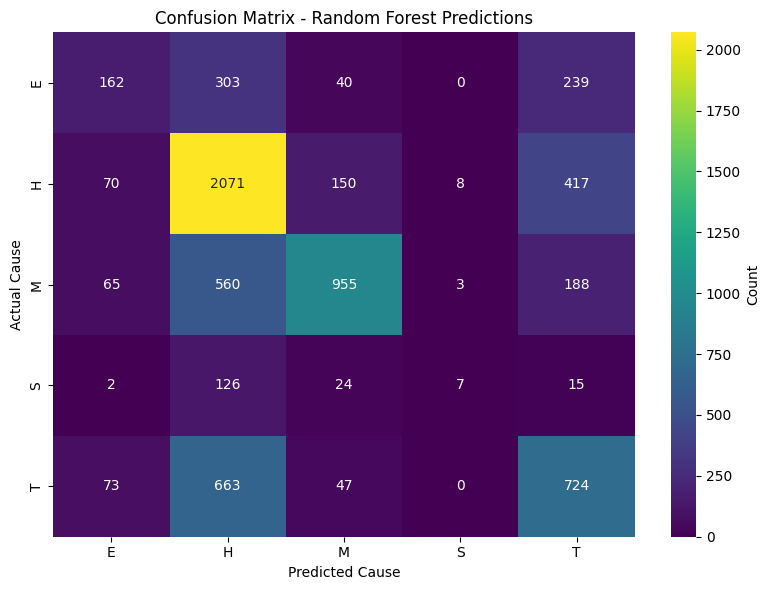


Confusion Matrix normalized by true label (rows sum to 1.0):
[[0.218 0.407 0.054 0.    0.321]
 [0.026 0.763 0.055 0.003 0.154]
 [0.037 0.316 0.539 0.002 0.106]
 [0.011 0.724 0.138 0.04  0.086]
 [0.048 0.44  0.031 0.    0.48 ]]


In [76]:
from sklearn.metrics import confusion_matrix
import numpy as np

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest Predictions')
plt.xlabel('Predicted Cause')
plt.ylabel('Actual Cause')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix normalized by true label (rows sum to 1.0):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(cm_normalized.round(3))

## Findings: Confusion Matrix Analysis

**Human Factor Prediction Bias:**
The model shows strong bias toward predicting Human Factor causes across all categories. When uncertain, the classifier defaults to Human Factor (the majority class at 39% of training data), leading to high false positive rates for this category.

**Per-Cause Accuracy Patterns:**
- Human Factor (H): 76.3% correctly identified - best performance, benefiting from majority class representation
- Mechanical (M): 53.9% correct, with 31.6% misclassified as Human Factor
- Track (T): 48.0% correct, with 44.0% misclassified as Human Factor
- Equipment (E): 21.8% correct, split between Human Factor (40.7%) and Track (32.1%) misclassifications
- Signal (S): 4.0% correct - effectively undetected, with 72.4% misclassified as Human Factor

**Cause Confusion Patterns:**
Equipment, Track, and Signal failures are frequently misclassified as Human Factor, suggesting these causes share similar operational contexts (track type, accident type combinations) in the feature space. The overlap indicates that distinguishing root causes requires information beyond the environmental and operational features captured in this model.

**Implications for ARM:**
ARM rules may struggle to separate Equipment, Track, and Signal causes from Human Factor using current features. Look for rules that successfully differentiate these overlapping categories - they may reveal conditions where cause distinction is clearest.

## Random Forest Baseline Assessment

The Random Forest model achieved 57% accuracy with significant class imbalance challenges - effectively defaulting to Human Factor predictions when uncertain. Feature importance analysis revealed that Accident Type and Track Type dominate predictive power, while environmental factors (Weather, Visibility) contribute minimally.

**Key Takeaways for ARM Analysis:**

The moderate baseline performance and substantial cause confusion (Equipment/Track/Signal often misclassified as Human Factor) indicate that our current feature set captures overlapping operational contexts rather than distinct cause signatures. This overlap will likely manifest in ARM as Human Factor rules dominating the discovered patterns.

**ARM Strategy Moving Forward:**

Rather than chasing balanced rule counts across causes, we'll mine rules on the full dataset and organize findings by cause category separately. Human Factor may generate 100+ rules while Signal produces only 5-10, but each set reveals interpretable patterns for that specific cause. We're prioritizing rule interpretability over prediction accuracy - the goal is discovering actionable "IF-THEN" relationships that explain when and why different accident causes occur, even if those patterns don't perfectly separate overlapping categories.

Expect ARM rules to heavily feature Accident Type and Track Type as primary antecedents, with geographic and environmental factors appearing as secondary modifiers.

## ARM Analysis: Initial 3-Feature Baseline

Run ARM analysis with a minimal feature set to establish baseline rule interpretability and demonstrate the relationship between feature count and rule complexity.

**Feature selection rationale:**
Selected three core features representing different dimensions of accident context: operational setting (Track Type), geographic classification (RUCC), and incident nature (Accident Type). This combination creates 26 binary features after one-hot encoding, generating approximately 67 million possible itemsets.

**Selected features:**
- Track Type (4 categories): Operational setting (Main, Yard, Industry, Siding)
- RUCC_2023 (9 categories): Rural-urban classification
- Accident Type (13 categories): Incident classification

**Parameters:**
- Minimum support: 3%
- Minimum confidence: 65%
- Minimum lift: 1.5

**Objective:**
Establish interpretable baseline rules for cause prediction with minimal feature complexity. Results will be compared to higher-cardinality feature sets to illustrate the trade-off between feature richness and rule interpretability.

In [77]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

df_merged = pd.read_csv("../data/processed/df_merged_features_complete.csv.zip")
df_encoded = pd.read_csv("../data/processed/df_encoded_features_complete.csv.zip")

# Select 3 features for initial ARM run
cols_3_features = ['Track Type', 'Accident Type', 'RUCC_2023']

# One-hot encode
df_ohe_3 = pd.get_dummies(
    df_merged[cols_3_features], 
    columns=cols_3_features, 
    dtype=int
)

# Add target variable
df_arm_3 = pd.concat([df_ohe_3, df_merged['Cause_Category']], axis=1)

# Create binary cause columns for ARM
cause_dummies = pd.get_dummies(df_arm_3['Cause_Category'], prefix='Cause')
df_arm_3 = pd.concat([df_arm_3.drop('Cause_Category', axis=1), cause_dummies], axis=1)

print(f"Shape after OHE: {df_arm_3.shape}")
print(f"Total binary features: {df_arm_3.shape[1]}")

# Generate frequent itemsets
frequent_itemsets_3 = apriori(df_arm_3, min_support=0.03, use_colnames=True)
print(f"\nFrequent itemsets found: {len(frequent_itemsets_3)}")

# Generate association rules
rules_3 = association_rules(frequent_itemsets_3, metric='lift', min_threshold=1.5)
rules_3 = rules_3[rules_3['confidence'] >= 0.65]

print(f"Rules generated: {len(rules_3)}")
rules_3.head(10)

/var/folders/h7/j749vy8n45n8p147xy2ll3vw0000gn/T/ipykernel_71878/3528826602.py:5: DtypeWarning: Columns (0: Persons Evacuated, 1: Division Code, 2: Train Direction Code, 3: Remote Control Locomotive Code, 4: First Car Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv("../data/processed/df_merged_features_complete.csv.zip")
/var/folders/h7/j749vy8n45n8p147xy2ll3vw0000gn/T/ipykernel_71878/3528826602.py:6: DtypeWarning: Columns (0: Persons Evacuated, 1: Division Code, 2: Train Direction Code, 3: Remote Control Locomotive Code, 4: First Car Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df_encoded = pd.read_csv("../data/processed/df_encoded_features_complete.csv.zip")
/Users/phillipromanmacbook/GitHub/rail-risk-census-analysis-521/.venv/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformanc

Shape after OHE: (34562, 31)
Total binary features: 31

Frequent itemsets found: 107
Rules generated: 29


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,frozenset({Accident Type_Hwy-rail crossing}),frozenset({Track Type_Main}),0.095307,0.336902,0.092616,0.971767,2.884422,1.0,0.060507,23.486510,0.722135,0.272727,0.957422,0.623336
5,frozenset({Accident Type_Obstruction}),frozenset({Track Type_Main}),0.042532,0.336902,0.034315,0.806803,2.394771,1.0,0.019986,3.432234,0.608296,0.099430,0.708645,0.454329
11,frozenset({Accident Type_Other impacts}),frozenset({Track Type_Yard}),0.147966,0.556565,0.129564,0.875636,1.573285,1.0,0.047212,3.565608,0.427668,0.225342,0.719543,0.554214
13,frozenset({Accident Type_Side collision}),frozenset({Track Type_Yard}),0.048869,0.556565,0.041693,0.853168,1.532916,1.0,0.014495,3.020007,0.365511,0.073958,0.668875,0.464040
14,frozenset({Cause_T}),frozenset({Accident Type_Derailment}),0.217985,0.553006,0.205630,0.943324,1.705810,1.0,0.085083,7.886771,0.529105,0.363715,0.873205,0.657582
16,frozenset({Accident Type_Hwy-rail crossing}),frozenset({Cause_M}),0.095307,0.256235,0.095047,0.997268,3.892002,1.0,0.070626,272.217927,0.821342,0.370558,0.996326,0.684101
20,frozenset({Accident Type_Side collision}),frozenset({Cause_H}),0.048869,0.392975,0.041722,0.853760,2.172555,1.0,0.022518,4.150872,0.567443,0.104274,0.759087,0.479965
22,"frozenset({Cause_T, Track Type_Industry})",frozenset({Accident Type_Derailment}),0.034778,0.553006,0.034604,0.995008,1.799272,1.0,0.015372,89.547760,0.460225,0.062556,0.988833,0.528792
32,"frozenset({Track Type_Main, Cause_T})",frozenset({Accident Type_Derailment}),0.063191,0.553006,0.054800,0.867216,1.568185,1.0,0.019855,3.366326,0.386760,0.097614,0.702940,0.483155
37,"frozenset({RUCC_2023_1, Accident Type_Hwy-rail...",frozenset({Track Type_Main}),0.039668,0.336902,0.038366,0.967177,2.870799,1.0,0.025002,20.202392,0.678583,0.113440,0.950501,0.540528


In [78]:
# Filter for rules predicting causes only
cause_rules_3_tr = rules_3[rules_3['consequents'].apply(
    lambda x: len(x) == 1 and any('Cause_' in str(item) for item in x)
)]

print(f"Cause prediction rules: {len(cause_rules_3_tr)}")
cause_rules_3_tr

Cause prediction rules: 6


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
16,frozenset({Accident Type_Hwy-rail crossing}),frozenset({Cause_M}),0.095307,0.256235,0.095047,0.997268,3.892002,1.0,0.070626,272.217927,0.821342,0.370558,0.996326,0.684101
20,frozenset({Accident Type_Side collision}),frozenset({Cause_H}),0.048869,0.392975,0.041722,0.853760,2.172555,1.0,0.022518,4.150872,0.567443,0.104274,0.759087,0.479965
40,"frozenset({Track Type_Main, Accident Type_Hwy-...",frozenset({Cause_M}),0.092616,0.256235,0.092443,0.998126,3.895350,1.0,0.068711,396.798536,0.819150,0.360528,0.997480,0.679449
68,"frozenset({Track Type_Yard, Accident Type_Side...",frozenset({Cause_H}),0.041693,0.392975,0.035704,0.856350,2.179146,1.0,0.019320,4.225715,0.564647,0.089492,0.763354,0.473603
82,"frozenset({RUCC_2023_1, Accident Type_Hwy-rail...",frozenset({Cause_M}),0.039668,0.256235,0.039552,0.997082,3.891279,1.0,0.029388,254.925395,0.773706,0.154289,0.996077,0.575721
86,"frozenset({RUCC_2023_1, Track Type_Main, Accid...",frozenset({Cause_M}),0.038366,0.256235,0.038308,0.998492,3.896778,1.0,0.028477,493.116081,0.773036,0.149469,0.997972,0.573997


## ARM Analysis: Equipment Type Feature Set (3 Features)

Run a second 3-feature ARM analysis using Equipment Type instead of Track Type to demonstrate the impact of high-cardinality features on rule generation and interpretability.

**Feature selection rationale:**
Equipment Type contains 14 categories compared to Track Type's 4 categories. This increases the total binary features after one-hot encoding from 26 to 36, expanding the possible itemset space from 67 million to 68 billion combinations. This comparison illustrates how feature cardinality affects ARM complexity and rule interpretability.

**Selected features:**
- Equipment Type (14 categories): Train operational type
- RUCC_2023 (9 categories): Rural-urban classification
- Accident Type (13 categories): Incident classification

**Parameters:**
- Minimum support: 3%
- Minimum confidence: 65%
- Minimum lift: 1.5

In [79]:
from mlxtend.frequent_patterns import apriori, association_rules

# Select 3 features - Equipment Type instead of Track Type
cols_3_eq = ['Equipment Type', 'Accident Type', 'RUCC_2023']

# One-hot encode
df_ohe_3_eq = pd.get_dummies(
    df_merged[cols_3_eq], 
    columns=cols_3_eq, 
    dtype=int
)

# Add target variable
df_arm_3_eq = pd.concat([df_ohe_3_eq, df_merged['Cause_Category']], axis=1)

# Create binary cause columns for ARM
cause_dummies = pd.get_dummies(df_arm_3_eq['Cause_Category'], prefix='Cause')
df_arm_3_eq = pd.concat([df_arm_3_eq.drop('Cause_Category', axis=1), cause_dummies], axis=1)

print(f"Shape after OHE: {df_arm_3_eq.shape}")
print(f"Total binary features: {df_arm_3_eq.shape[1]}")

# Generate frequent itemsets
frequent_itemsets_3_eq = apriori(df_arm_3_eq, min_support=0.03, use_colnames=True)
print(f"\nFrequent itemsets found: {len(frequent_itemsets_3_eq)}")

# Generate association rules
rules_3_eq = association_rules(frequent_itemsets_3_eq, metric='lift', min_threshold=1.5)
rules_3_eq = rules_3_eq[rules_3_eq['confidence'] >= 0.65]

print(f"Rules generated: {len(rules_3_eq)}")

# Filter for cause predictions only
cause_rules_3_eq = rules_3_eq[rules_3_eq['consequents'].apply(
    lambda x: len(x) == 1 and any('Cause_' in str(item) for item in x)
)]

print(f"Cause prediction rules: {len(cause_rules_3_eq)}")
cause_rules_3_eq

Shape after OHE: (34562, 41)
Total binary features: 41


/Users/phillipromanmacbook/GitHub/rail-risk-census-analysis-521/.venv/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Frequent itemsets found: 93
Rules generated: 11
Cause prediction rules: 5


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({Equipment Type_Light loco(s)}),frozenset({Cause_H}),0.049042,0.392975,0.032550,0.663717,1.688955,1.0,0.013278,1.805101,0.428955,0.079494,0.446014,0.373274
6,frozenset({Accident Type_Hwy-rail crossing}),frozenset({Cause_M}),0.095307,0.256235,0.095047,0.997268,3.892002,1.0,0.070626,272.217927,0.821342,0.370558,0.996326,0.684101
10,frozenset({Accident Type_Side collision}),frozenset({Cause_H}),0.048869,0.392975,0.041722,0.853760,2.172555,1.0,0.022518,4.150872,0.567443,0.104274,0.759087,0.479965
20,"frozenset({Accident Type_Hwy-rail crossing, Eq...",frozenset({Cause_M}),0.050258,0.256235,0.050229,0.999424,3.900418,1.0,0.037351,1291.919507,0.782967,0.196003,0.999226,0.597725
38,"frozenset({RUCC_2023_1, Accident Type_Hwy-rail...",frozenset({Cause_M}),0.039668,0.256235,0.039552,0.997082,3.891279,1.0,0.029388,254.925395,0.773706,0.154289,0.996077,0.575721


In [84]:
# Combine 3-feature runs into one dataframe
cause_rules_3_track = cause_rules_3_tr.copy()
cause_rules_3_track['feature_set'] = '3_features_track'

cause_rules_3_eq_copy = cause_rules_3_eq.copy()
cause_rules_3_eq_copy['feature_set'] = '3_features_equipment'

rules_3_combined = pd.concat([cause_rules_3_track, cause_rules_3_eq_copy], ignore_index=True)

# Save combined 3-feature rules
rules_3_combined.to_csv('../data/processed/arm_rules/arm_rules_3_features.csv', index=False)
print(f"Saved {len(rules_3_combined)} rules from 3-feature runs")

Saved 11 rules from 3-feature runs


## Findings: Comparison of 3-Feature ARM Runs

**Feature Set Comparison:**
- Track Type set: 26 binary features → 107 itemsets → 29 rules → 6 cause rules
- Equipment Type set: 36 binary features → 93 itemsets → 11 rules → 5 cause rules

**Unexpected Result:**
Equipment Type contains 14 categories compared to Track Type's 4, creating 10 additional binary features after one-hot encoding. Despite this higher cardinality, the Equipment Type set generated fewer frequent itemsets and fewer rules overall. This counterintuitive outcome demonstrates that feature cardinality alone does not determine rule quantity.

**Why Equipment Type Underperformed:**
Equipment Type categories are more sparse across the dataset. Many equipment types (DMU, Commuter trains, Maintenance cars) represent small percentages of accidents and fail to meet the 3% minimum support threshold individually. This fragmentation prevents frequent itemset formation, reducing the total rule count despite having more category options.

**Rule Content Analysis:**
Both feature sets discovered similar high-confidence patterns:
- Highway-rail crossing accidents predict Mechanical causes (97-100% confidence, lift ~3.9)
- Side collision accidents predict Human causes (85% confidence, lift ~2.2)
- RUCC metro areas combined with highway-rail crossings reinforce Mechanical predictions

Equipment Type contributed only two unique rules:
- Light locomotives → Human Factor (66% confidence, lift 1.7) - relatively weak
- Freight trains + Highway-rail crossing → Mechanical (100% confidence) - reinforces existing pattern

**Key Insight:**
Track Type, despite having fewer categories, provided stronger operational context for cause prediction. Equipment Type's higher granularity fragmented the data without adding substantial new predictive patterns. Accident Type dominated both analyses as the primary driver of cause associations.

**Implications for Full Feature Set:**
Adding more high-cardinality features may not proportionally increase meaningful rules. Feature selection should prioritize predictive signal and distribution balance over category count.

## ARM Analysis: Full 6-Feature Model

Run ARM analysis with the complete feature set selected through Phase 2 statistical testing and correlation analysis. This represents the final model configuration that balances feature richness with interpretability constraints.

**Feature selection rationale:**
Six features spanning operational, environmental, and geographic dimensions were selected based on chi-square significance testing, correlation analysis with Bonferroni correction, and domain relevance. Track Type and Accident Type provide operational context, Weather and Visibility capture environmental conditions, while RUCC and Census Region represent geographic patterns at different scales.

**Selected features:**
- Weather Condition (6 categories): Environmental conditions
- Track Type (4 categories): Operational setting
- Visibility (4 categories): Lighting conditions
- Region (4 categories): US Census geographic regions
- RUCC_2023 (9 categories): Rural-urban classification
- Accident Type (13 categories): Incident classification

**Total feature space:**
40 binary features after one-hot encoding, creating approximately 1 trillion possible itemsets (2^40 - 1).

**Parameters:**
- Minimum support: 5% (increased from 3% to manage complexity)
- Minimum confidence: 70% (increased from 65% for higher reliability)
- Minimum lift: 2.0 (increased from 1.5 for stronger associations)

**Objective:**
Generate robust cause prediction rules that balance coverage with interpretability. Compare rule quantity, complexity, and predictive patterns against 3-feature baseline to quantify the trade-off between feature richness and rule actionability.

In [80]:
# Run 1: High thresholds, all accident types
frequent_itemsets_6_high = apriori(df_arm_6, min_support=0.05, use_colnames=True)

rules_6_high = association_rules(frequent_itemsets_6_high, metric='lift', min_threshold=2.0)
rules_6_high = rules_6_high[rules_6_high['confidence'] >= 0.70]

cause_rules_6_high = rules_6_high[rules_6_high['consequents'].apply(
    lambda x: len(x) == 1 and any('Cause_' in str(item) for item in x)
)]

cause_rules_6_high.to_csv('../data/processed/arm_rules/arm_rules_6_features_high_threshold.csv', index=False)
print(f"Saved Run 1: {len(cause_rules_6_high)} rules (high threshold, all accidents)")

cause_rules_6_high

/Users/phillipromanmacbook/GitHub/rail-risk-census-analysis-521/.venv/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Saved Run 1: 6 rules (high threshold, all accidents)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,frozenset({Accident Type_Hwy-rail crossing}),frozenset({Cause_M}),0.095307,0.256235,0.095047,0.997268,3.892002,1.0,0.070626,272.217927,0.821342,0.370558,0.996326,0.684101
8,"frozenset({Accident Type_Hwy-rail crossing, We...",frozenset({Cause_M}),0.069296,0.256235,0.069093,0.997077,3.891258,1.0,0.051337,254.473823,0.798335,0.269435,0.996070,0.633362
16,"frozenset({Track Type_Main, Accident Type_Hwy-...",frozenset({Cause_M}),0.092616,0.256235,0.092443,0.998126,3.895350,1.0,0.068711,396.798536,0.819150,0.360528,0.997480,0.679449
22,"frozenset({Visibility_Day, Accident Type_Hwy-r...",frozenset({Cause_M}),0.059892,0.256235,0.059748,0.997585,3.893238,1.0,0.044401,307.918639,0.790489,0.233044,0.996752,0.615380
26,"frozenset({Track Type_Main, Accident Type_Hwy-...",frozenset({Cause_M}),0.066952,0.256235,0.066836,0.998271,3.895919,1.0,0.049681,430.267953,0.796659,0.260722,0.997676,0.629556
38,"frozenset({Visibility_Day, Track Type_Main, Ac...",frozenset({Cause_M}),0.058504,0.256235,0.058388,0.998022,3.894944,1.0,0.043397,375.973121,0.789442,0.227765,0.997340,0.612945


## Findings: 6-Feature ARM - High Threshold Run

**Parameters:** Support ≥ 5%, Confidence ≥ 70%, Lift ≥ 2.0

**Results:** 6 cause prediction rules generated, all predicting Mechanical causes.

**Dominant Pattern:**
Highway-rail crossing accidents show an overwhelming association with Mechanical causes (100% confidence, lift 3.9). This pattern is so strong that all discovered rules are variations adding environmental or operational context to the core Hwy-rail crossing → Mechanical relationship.

**Rule Variations:**
- Hwy-rail crossing alone → Mechanical
- Hwy-rail crossing + Clear weather → Mechanical
- Hwy-rail crossing + Main track → Mechanical  
- Hwy-rail crossing + Day visibility → Mechanical
- Combinations of above conditions → Mechanical

**Missing Causes:**
No rules discovered for Human Factor, Track, Equipment, or Signal causes at these conservative thresholds. The Hwy-rail crossing pattern dominates the frequent itemset space, preventing other cause associations from meeting the 5% support and 2.0 lift thresholds simultaneo

In [81]:
from mlxtend.frequent_patterns import apriori, association_rules

# Run 2: Lower thresholds, filter out Hwy-rail
# Use same OHE data from previous run (df_arm_6)

# Generate frequent itemsets with lower support
frequent_itemsets_6_low = apriori(df_arm_6, min_support=0.02, use_colnames=True)
print(f"Frequent itemsets found: {len(frequent_itemsets_6_low)}")

# Generate association rules with lower thresholds
rules_6_low = association_rules(frequent_itemsets_6_low, metric='lift', min_threshold=1.5)
rules_6_low = rules_6_low[rules_6_low['confidence'] >= 0.70]

print(f"Rules generated: {len(rules_6_low)}")

# Filter for cause predictions only
cause_rules_6_low = rules_6_low[rules_6_low['consequents'].apply(
    lambda x: len(x) == 1 and any('Cause_' in str(item) for item in x)
)]

# Filter out Hwy-rail crossing rules
cause_rules_6_low_no_hwy = cause_rules_6_low[~cause_rules_6_low['antecedents'].apply(
    lambda x: any('Hwy-rail crossing' in str(item) for item in x)
)]

print(f"Cause prediction rules (no Hwy-rail): {len(cause_rules_6_low_no_hwy)}")

# Save immediately
cause_rules_6_low_no_hwy.to_csv('../data/processed/arm_rules/arm_rules_6_features_low_threshold_no_hwy.csv', index=False)
print(f"Saved {len(cause_rules_6_low_no_hwy)} rules to arm_rules_6_features_low_threshold_no_hwy.csv")

cause_rules_6_low_no_hwy


/Users/phillipromanmacbook/GitHub/rail-risk-census-analysis-521/.venv/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent itemsets found: 1069
Rules generated: 198
Cause prediction rules (no Hwy-rail): 6
Saved 6 rules to arm_rules_6_features_low_threshold_no_hwy.csv


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
32,frozenset({Accident Type_Side collision}),frozenset({Cause_H}),0.048869,0.392975,0.041722,0.853760,2.172555,1.0,0.022518,4.150872,0.567443,0.104274,0.759087,0.479965
66,"frozenset({Accident Type_Side collision, Weath...",frozenset({Cause_H}),0.033274,0.392975,0.028586,0.859130,2.186222,1.0,0.015511,4.309128,0.561265,0.071886,0.767935,0.465937
162,"frozenset({Track Type_Main, Accident Type_Obst...",frozenset({Cause_M}),0.034315,0.256235,0.024680,0.719224,2.806891,1.0,0.015888,2.648964,0.666609,0.092828,0.622494,0.407772
206,"frozenset({Track Type_Yard, Accident Type_Side...",frozenset({Cause_H}),0.041693,0.392975,0.035704,0.856350,2.179146,1.0,0.019320,4.225715,0.564647,0.089492,0.763354,0.473603
270,"frozenset({RUCC_2023_1, Accident Type_Side col...",frozenset({Cause_H}),0.025548,0.392975,0.021816,0.853907,2.172930,1.0,0.011776,4.155063,0.553944,0.054992,0.759330,0.454711
426,"frozenset({Track Type_Yard, Accident Type_Side...",frozenset({Cause_H}),0.028008,0.392975,0.024159,0.862603,2.195059,1.0,0.013153,4.418047,0.560119,0.060882,0.773656,0.462041


## Findings: 6-Feature ARM - Low Threshold, No Highway-Rail Crossing

**Parameters:** Support ≥ 2%, Confidence ≥ 70%, Lift ≥ 1.5, Hwy-rail crossing filtered out

**Results:** 6 cause prediction rules generated, revealing patterns for Human Factor and Mechanical causes.

**Discovered Patterns:**

*Human Factor (5 rules):*
Side collision accidents strongly predict Human Factor causes (85-86% confidence, lift 2.2). Environmental and operational conditions add context:
- Side collision alone → Human Factor
- Side collision + Clear weather → Human Factor
- Side collision + Yard track → Human Factor
- Side collision + Metro area (RUCC_1) → Human Factor
- Side collision + Yard + Clear weather → Human Factor

*Mechanical (1 rule):*
- Main track + Obstruction → Mechanical (72% confidence, lift 2.8)

**Pattern Analysis:**
Similar to the high threshold run where Hwy-rail crossing dominated Mechanical predictions, Side collision dominates Human Factor predictions in the non-Hwy-rail space. The discovered rules represent variations adding geographic and operational context to this core association.

**Missing Causes:**
No rules discovered for Track, Equipment, or Signal causes even with relaxed thresholds and dominant pattern removal. These minority classes (Track 22%, Equipment 11%, Signal 2.5%) likely require further threshold reduction or alternative feature combinations to generate discoverable patterns.

**Implication:**
Filtering out the dominant Hwy-rail crossing pattern revealed Human Factor associations but maintained similar pattern concentration around Side collision accidents. Two accident types (Hwy-rail crossing, Side collision) drive the majority of discoverable cause associations in this feature space.

## Summary: Comparing High and Low Threshold ARM Runs

**Methodological Approach:**
We conducted two ARM runs with identical features but different threshold configurations to balance rule reliability with pattern diversity for CBA feature engineering.

**Run Comparison:**

*High Threshold Run (Support ≥5%, Confidence ≥70%, Lift ≥2.0):*
- 6 rules generated, all predicting Mechanical causes
- Dominated by Highway-rail crossing → Mechanical pattern (100% confidence)
- High reliability but zero cause diversity

*Low Threshold Run (Support ≥2%, Confidence ≥70%, Lift ≥1.5, No Hwy-rail):*
- 6 rules generated, predicting Human Factor (5 rules) and Mechanical (1 rule)
- Dominated by Side collision → Human Factor pattern (85% confidence)
- Revealed alternative cause associations after removing dominant signal

**Why We Ran Two Configurations:**

ARM serves as feature engineering for CBA - the discovered rules become candidate features that CBA evaluates for classification performance. Running multiple threshold configurations provides CBA with a richer pool of rule candidates representing different trade-offs:

1. **Reliability vs Diversity Trade-off:** High thresholds produce highly confident rules (100% for Hwy-rail) but miss alternative patterns. Low thresholds with filtering reveal additional cause associations (Human Factor rules) that high thresholds suppressed.

2. **Feature Pool Expansion:** CBA will test which rules actually improve classification. Providing both conservative (high confidence) and exploratory (lower threshold, filtered) rules lets the model determine which combinations work best rather than committing upfront to one strategy.

3. **Dominant Pattern Management:** Highway-rail crossing's extreme association with Mechanical causes (lift 3.9) overshadowed all other patterns at high thresholds. Filtering this dominant accident type revealed that Side collision similarly drives Human Factor predictions - a pattern invisible when Hwy-rail rules monopolized the frequent itemset space.

**Key Insight:**
Both runs demonstrate that accident type dominates cause prediction in this feature space. Two specific accident types (Highway-rail crossing, Side collision) account for all discovered rules across both configurations. Environmental factors (Weather, Visibility) and geographic factors (Region, RUCC) appear only as rule modifiers, never as primary drivers of cause associations.

**Implications for CBA:**
The 12 total rules (6 from each run) provide CBA with:
- Strong Mechanical indicators (Hwy-rail crossing rules)
- Strong Human Factor indicators (Side collision rules)  
- Limited coverage for Track, Equipment, and Signal causes

CBA performance will likely reflect this pattern concentration - strong accuracy for Mechanical and Human Factor causes, weak performance for minority classes. This mirrors the Random Forest baseline where the same cause imbalance appeared.

In [82]:
# Save Run 1 (high threshold, all accident types)
cause_rules_6.to_csv('../data/processed/arm_rules/arm_rules_6_features_high_threshold.csv', index=False)
print(f"Saved Run 1: {len(cause_rules_6)} rules (high threshold, all accidents)")

# Already saved Run 2 above
print(f"Saved Run 2: {len(cause_rules_6_low_no_hwy)} rules (low threshold, no hwy-rail)")

Saved Run 1: 32 rules (high threshold, all accidents)
Saved Run 2: 6 rules (low threshold, no hwy-rail)
